In [25]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [26]:
!uv pip install --upgrade seaborn matplotlib

Using Python 3.12.7 environment at: C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv
Resolved 14 packages in 162ms
Prepared 5 packages in 3ms
Uninstalled 5 packages in 890ms
Installed 5 packages in 707ms
 - fonttools==4.61.1
 + fonttools==4.62.1
 - kiwisolver==1.4.9
 + kiwisolver==1.5.0
 - numpy==2.4.2
 + numpy==2.4.3
 - pandas==2.3.3
 + pandas==3.0.1
 - seaborn==0.12.2
 + seaborn==0.13.2


In [27]:
import pandas as pd
pd.set_option('display.max_columns', None)
df = catalog.load("domy_fill_missing_values")
df = df.sort_index(axis=1)

cat_features_s = []
cat_features_b = []
num_features = []

for col in df.columns:
    if (df[col].dtype in ['object', 'string'] and df[col].nunique() < 10):
        cat_features_s.append(col)
    elif df[col].dtype in ['object', 'string'] and df[col].nunique() >= 10:
        cat_features_b.append(col)
    else:
        num_features.append(col)
cat_features_s

[03/21/26 23:07:29] INFO     Loading data from domy_fill_missing_values (CSVDataset)...        ]8;id=134883;file://C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=631628;file://C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\


[
    'Alley',
    'BldgType',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'BsmtQual',
    'CentralAir',
    'Condition1',
    'Condition2',
    'Electrical',
    'ExterCond',
    'ExterQual',
    'Fence',
    'FireplaceQu',
    'Foundation',
    'Functional',
    'GarageCond',
    'GarageFinish',
    'GarageQual',
    'GarageType',
    'Heating',
    'HeatingQC',
    'HouseStyle',
    'KitchenQual',
    'LandContour',
    'LandSlope',
    'LotConfig',
    'LotShape',
    'MSZoning',
    'MasVnrType',
    'MiscFeature',
    'PavedDrive',
    'PoolQC',
    'RoofMatl',
    'RoofStyle',
    'SaleCondition',
    'SaleType',
    'Street',
    'Utilities'
]

In [28]:
cat_features_s.append('BsmtFinType1Ovrl')
cat_features_s.append('IsStandardElectrical')
cat_features_s.append('FenceOvrl')
cat_features_s.append('IsFlat')   
# for col in df:
#     print(col + ": " + str(df[col].dtype))

In [29]:
import pandas as pd

threshold = 0.95
cols_to_drop = []
for col in df.columns:
    max_freq = df[col].value_counts(normalize=True, dropna=False).max()
   # print(col + ": " + str(max_freq))
    if max_freq >= threshold and df[col].dtype in ['object', 'string']:
        cols_to_drop.append(col)    
print(f"Usunięto {len(cols_to_drop)} kolumn zdominowanych w >={threshold*100}%:")
print(cols_to_drop)
for col in cols_to_drop:
    df.drop(col, axis=1, inplace=True)

mapowanie_ocen = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'Lack': 0}
kolumny_do_zmiany = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu',
                    'GarageQual', 'GarageCond'] 

for kol in kolumny_do_zmiany:
    df[kol] = df[kol].map(mapowanie_ocen)

freq = df['BldgType'].value_counts(normalize=True)
df['BldgType'] = df['BldgType'].replace(freq[freq < 0.1].index.tolist(), 'Other')

grades = {
    'Lack': 0,
    'No': 1,
    'Mn': 2,
    'Av': 3,
    'Gd': 4
}
df['BsmtExposure'] = df['BsmtExposure'].map(grades)

grades = {
    'Lack': 0,
    'Unf': 1,
    'LwQ': 2,
    'Rec': 3,
    'BLQ': 4,
    'ALQ': 5,
    'GLQ': 6  
}
df['BsmtFinType1'] = df['BsmtFinType1'].map(grades)
df.rename(columns={'BsmtFinType1': 'BsmtFinType1Ovrl'}, inplace=True)

df.drop('BsmtFinType2', axis=1, inplace=True)

df['CentralAir'] = df['CentralAir'].map({'Y': 1, 'N': 0})

grades = {
    'Artery': 'Noise',
    'RRAn': 'Noise',
    'RRAe': 'Noise',
    'Feedr': 'Noise',
    'RRNn': 'Noise',
    'RRNe': 'Noise',
    'Norm': 'Norm',
    'PosN': 'Pos',
    'PosA': 'Pos'
}
df['Condition1'] = df['Condition1'].map(grades)

df['Electrical'] = df['Electrical'].apply(lambda x: 1 if x == 'SBrkr' else 0)
df = df.rename(columns={'Electrical': 'IsStandardElectrical'})

grades = {
    'NoFence': 0,
    'MnPrv': 1,
    'MnWw': 1,
    'GdWo': 2,
    'GdPrv': 2}
df['Fence'] = df['Fence'].map(grades)
df.rename(columns={'Fence': 'FenceOvrl'}, inplace=True)

freq = df['Foundation'].value_counts(normalize=True)
df['Foundation'] = df['Foundation'].replace(freq[freq < 0.11].index.tolist(), 'Other')

df.drop('Functional', axis=1, inplace=True)

grades = {
    'Lack': 0,
    'Unf': 1,
    'RFn': 2,
    'Fin': 3
}
df['GarageFinish'] = df['GarageFinish'].map(grades)

freq = df['GarageType'].value_counts(normalize=True)
df['GarageType'] = df['GarageType'].replace(freq[freq < 0.07].index.tolist(), 'Other')

freq = df['HouseStyle'].value_counts(normalize=True)
df['HouseStyle'] = df['HouseStyle'].replace(freq[freq < 0.11].index.tolist(), 'Other')

df['LandContour'] = df['LandContour'].apply(lambda x: 1 if x == 'Lvl' else 0)
df = df.rename(columns={'LandContour': 'IsFlat'})

grades = {
    'IR3': 1,
    'IR2': 2,
    'IR1': 3,
    'Reg': 4
}
df['LotShape'] = df['LotShape'].map(grades)

df['MSZoning'] = df['MSZoning'].replace(['FV', 'RH', "'C (all)'"], 'Other')

df['MasVnrType'] = df['MasVnrType'].replace(['BrkFace', 'BrkCmn'], 'Brick')

df['PavedDrive'] = df['PavedDrive'].map({'Y': 1, 'N': 0, 'P': 1})

freq = df['RoofStyle'].value_counts(normalize=True)
df['RoofStyle'] = df['RoofStyle'].replace(freq[freq < 0.1].index.tolist(), 'Other')

freq = df['SaleCondition'].value_counts(normalize=True)
df['SaleCondition'] = df['SaleCondition'].replace(freq[freq < 0.03].index.tolist(), 'Other')

freq = df['SaleType'].value_counts(normalize=True)
df['SaleType'] = df['SaleType'].replace(freq[freq < 0.025].index.tolist(), 'Other')

Usunięto 7 kolumn zdominowanych w >=95.0%:
['Condition2', 'Heating', 'MiscFeature', 'PoolQC', 'RoofMatl', 'Street', 'Utilities']


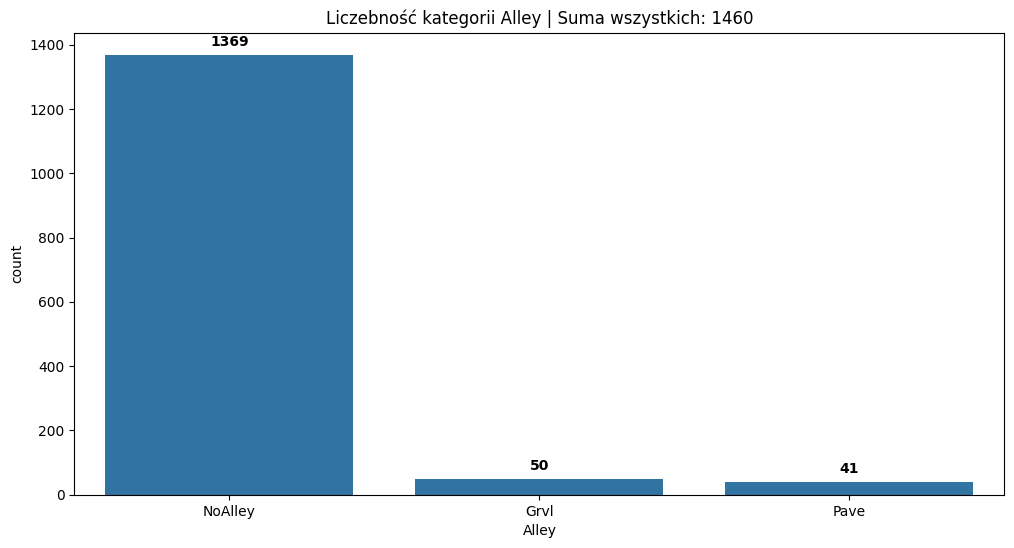

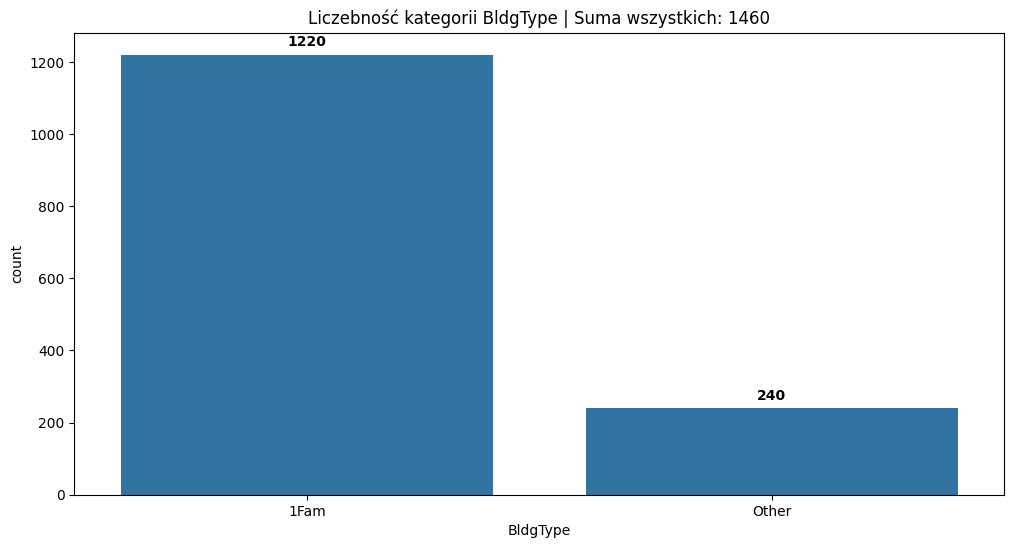

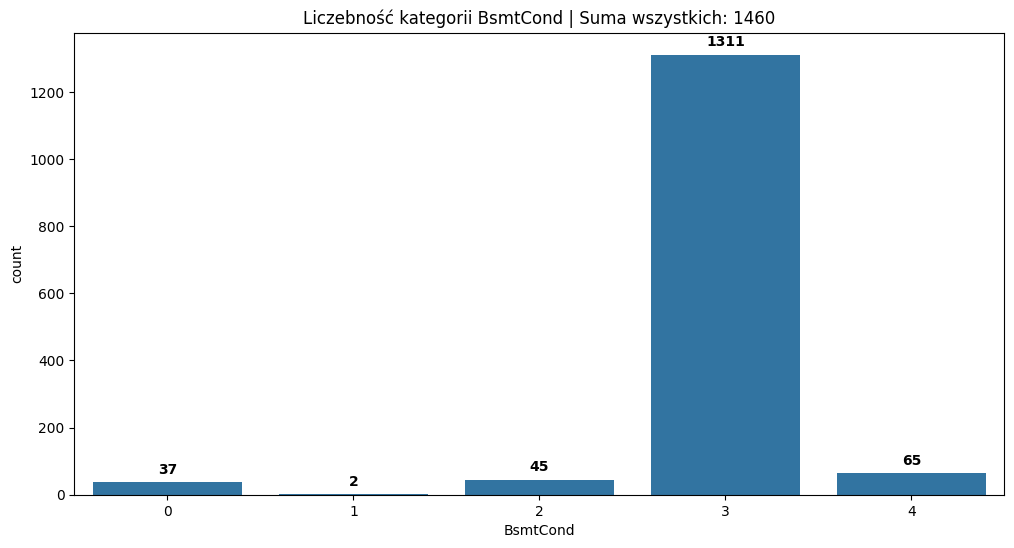

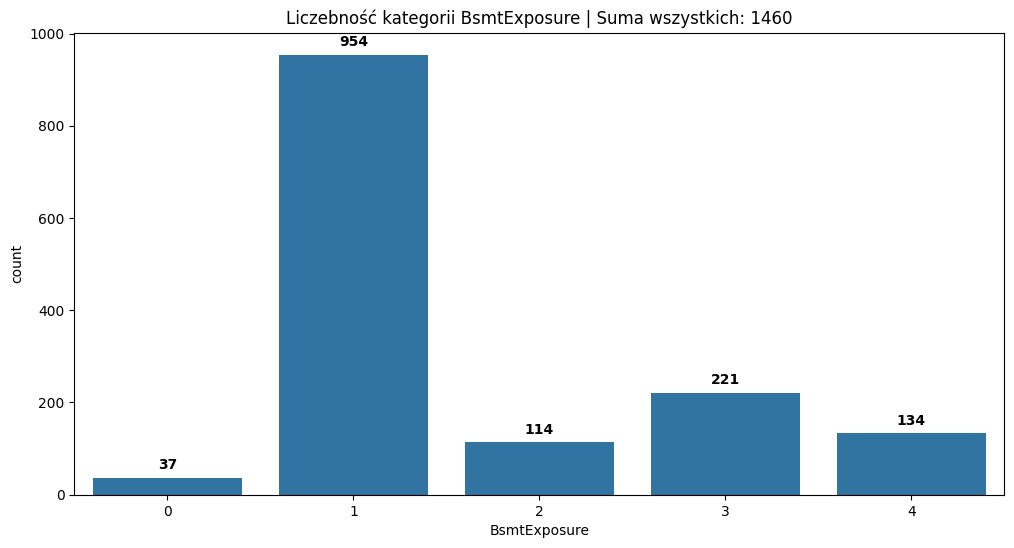

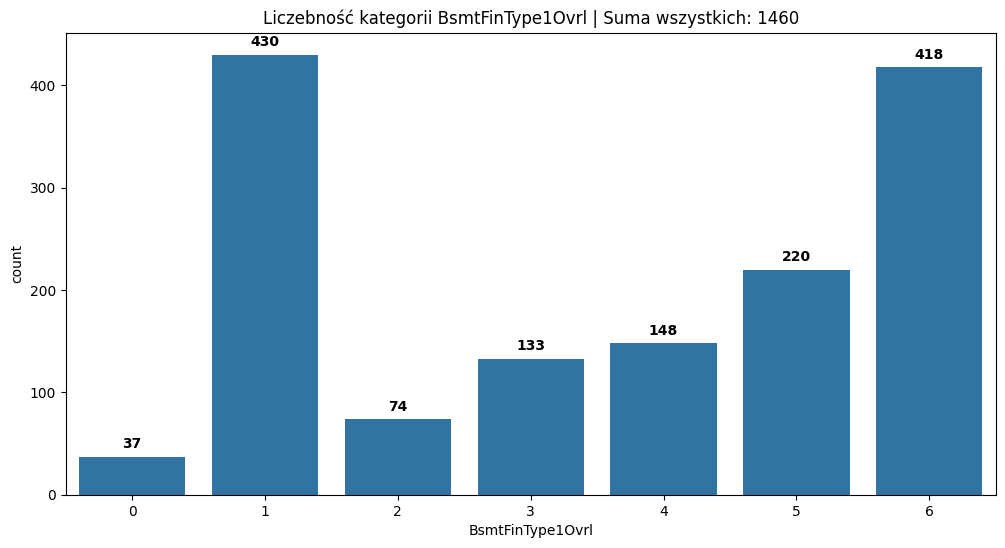

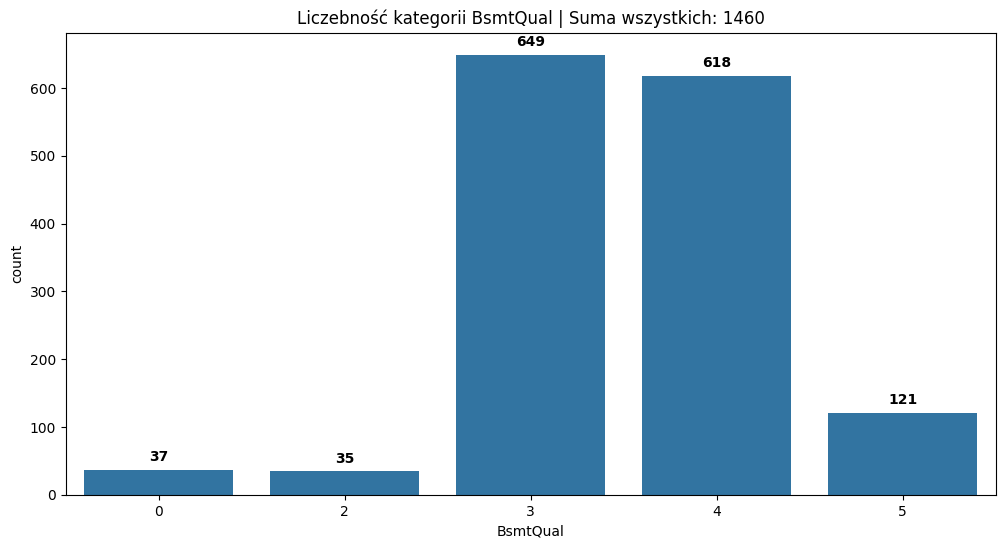

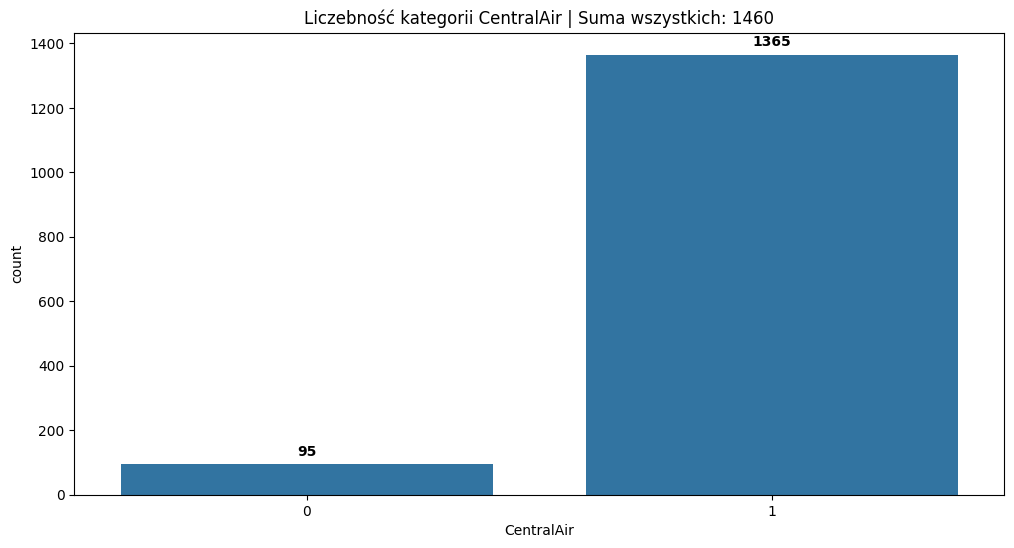

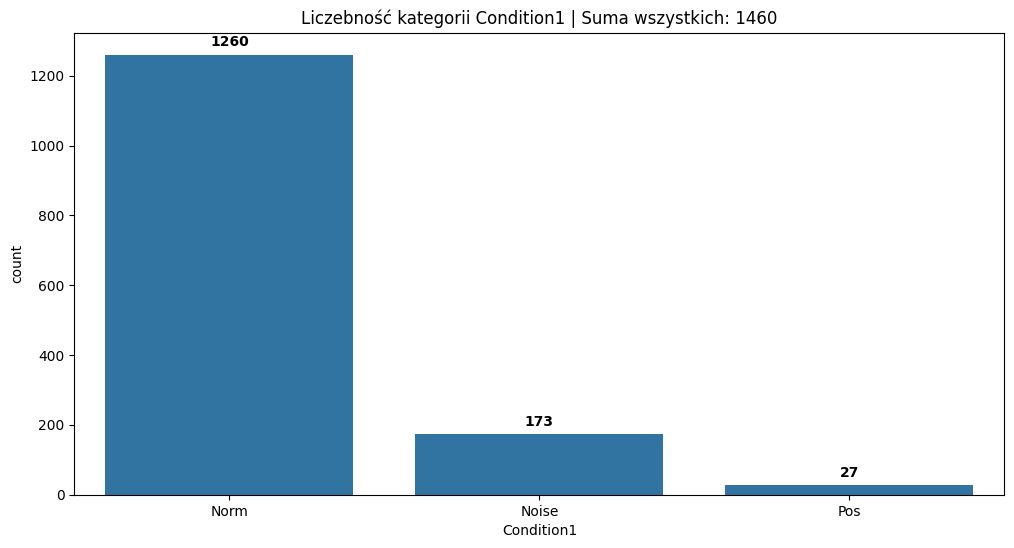

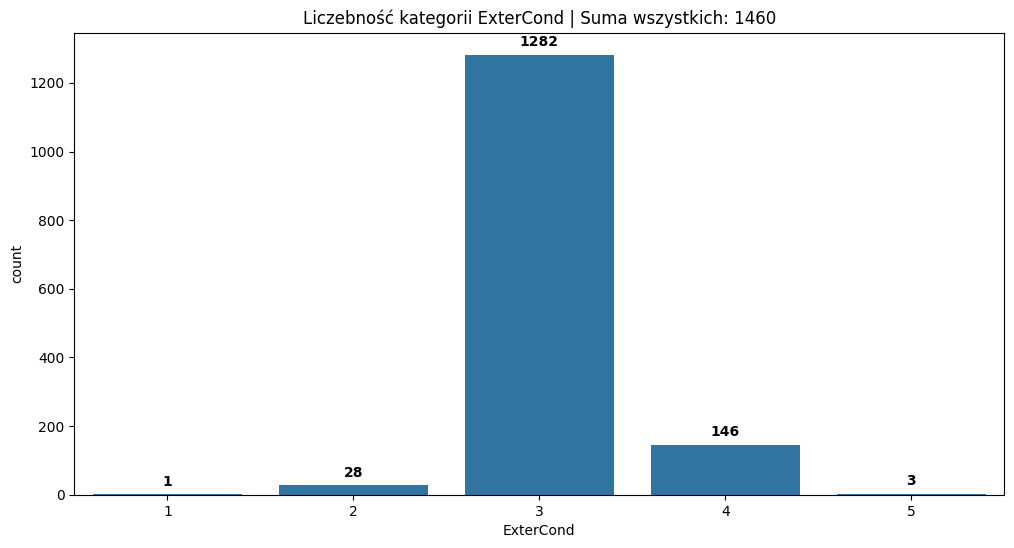

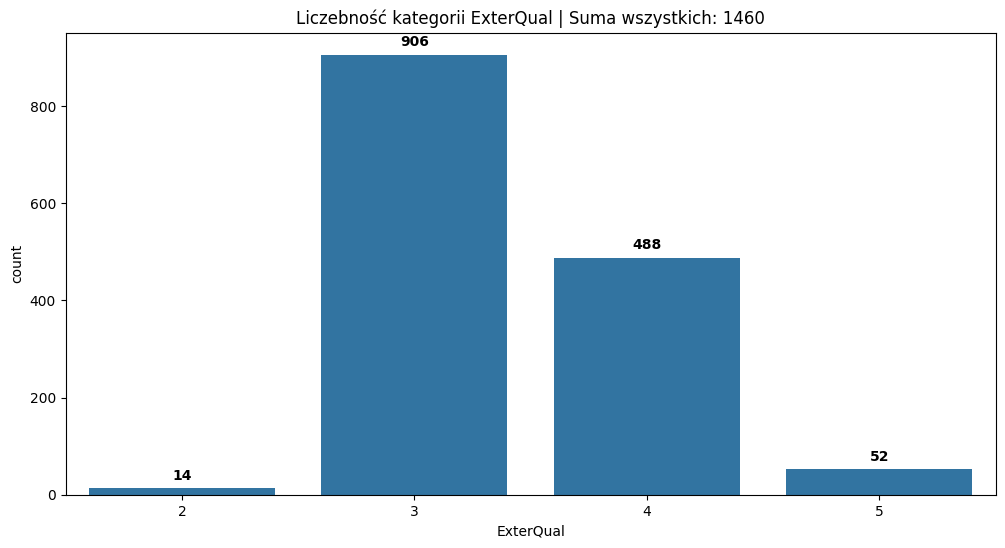

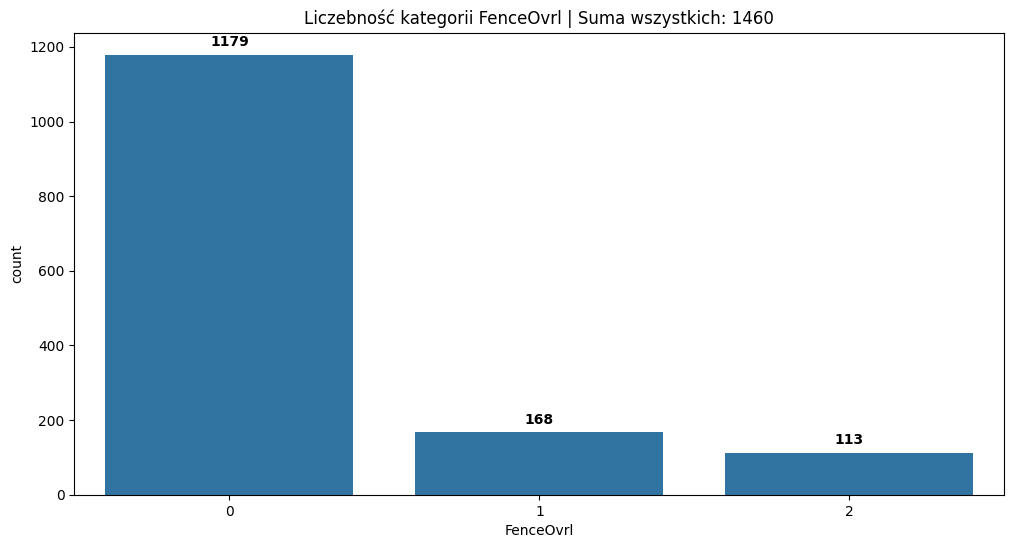

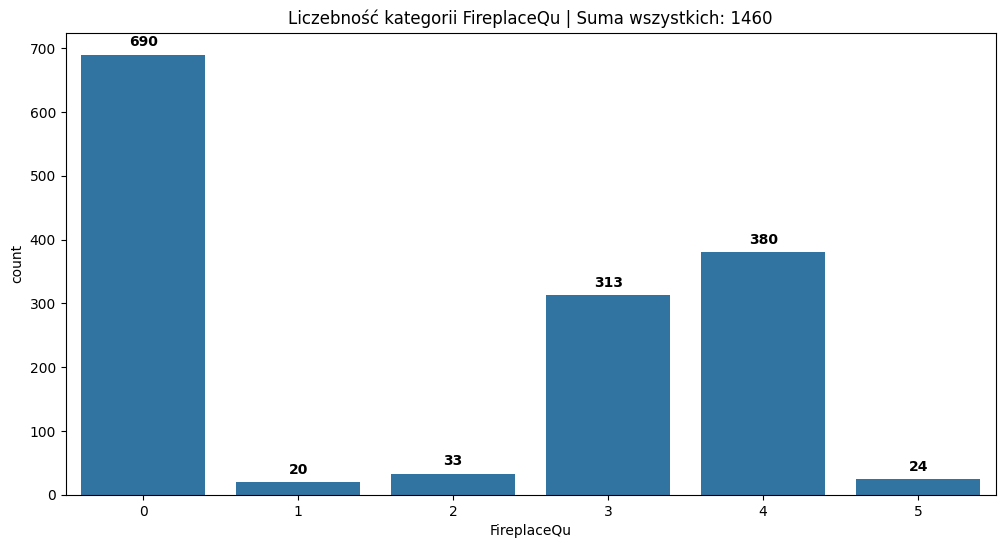

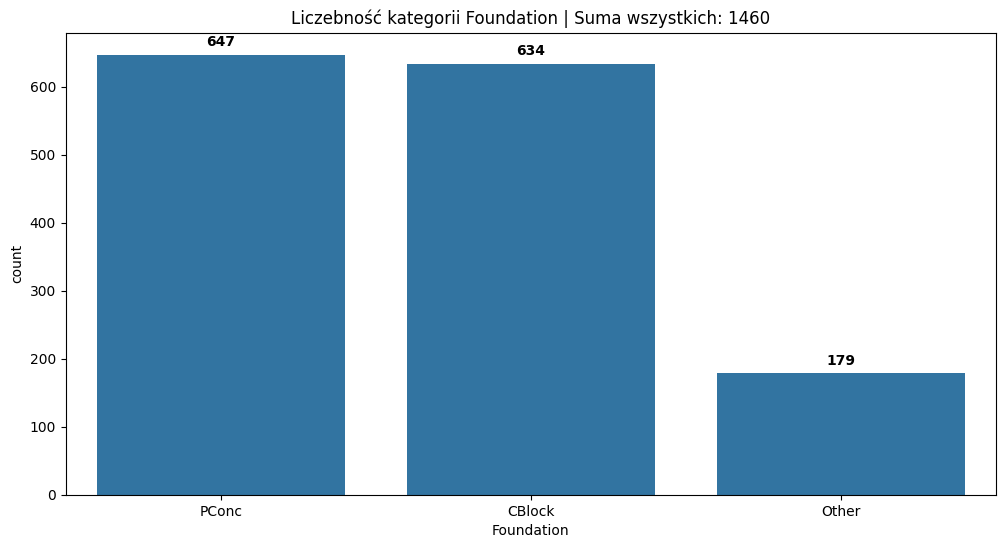

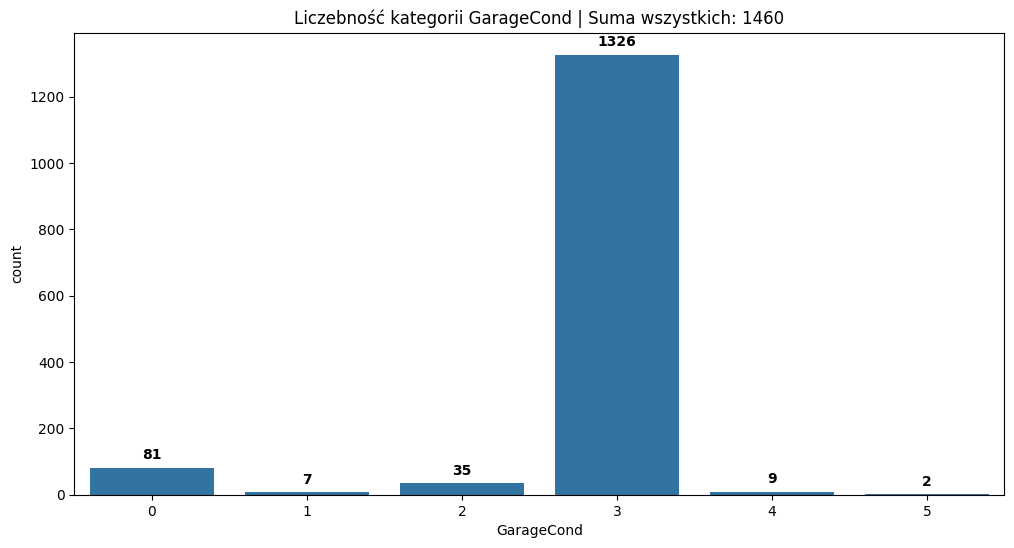

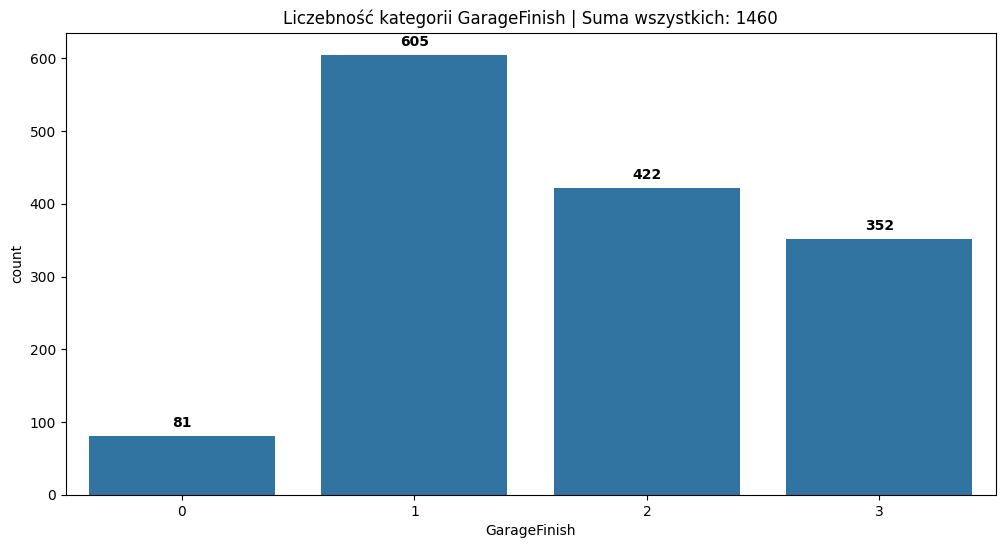

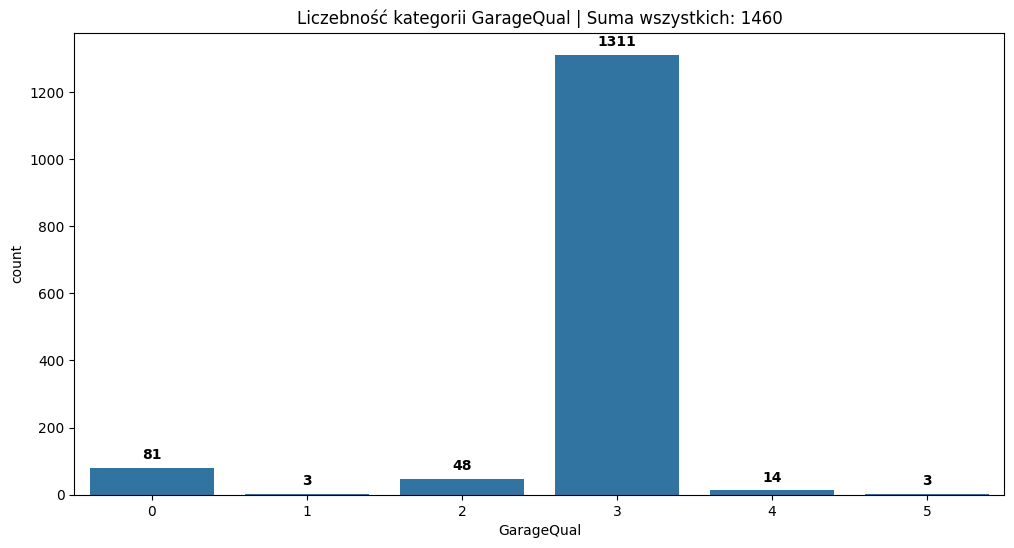

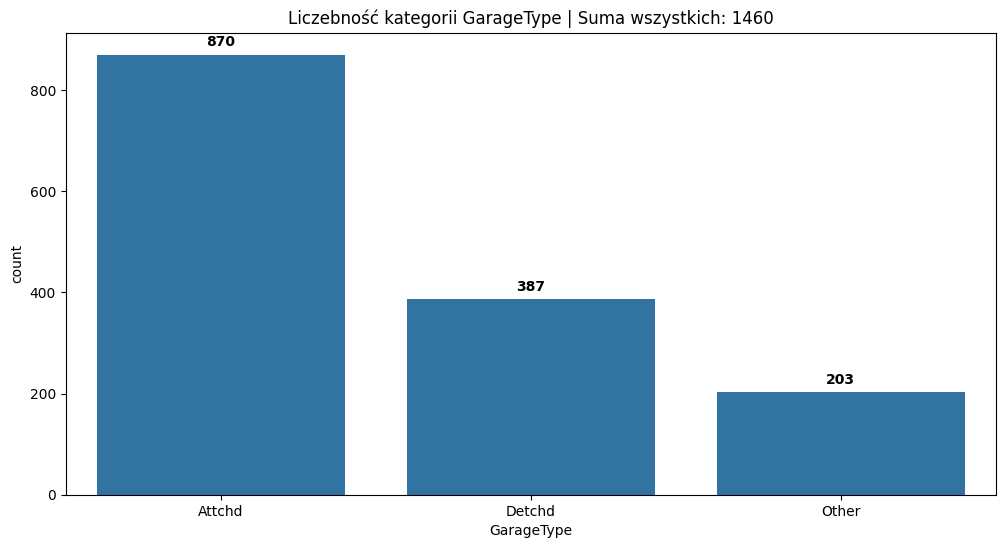

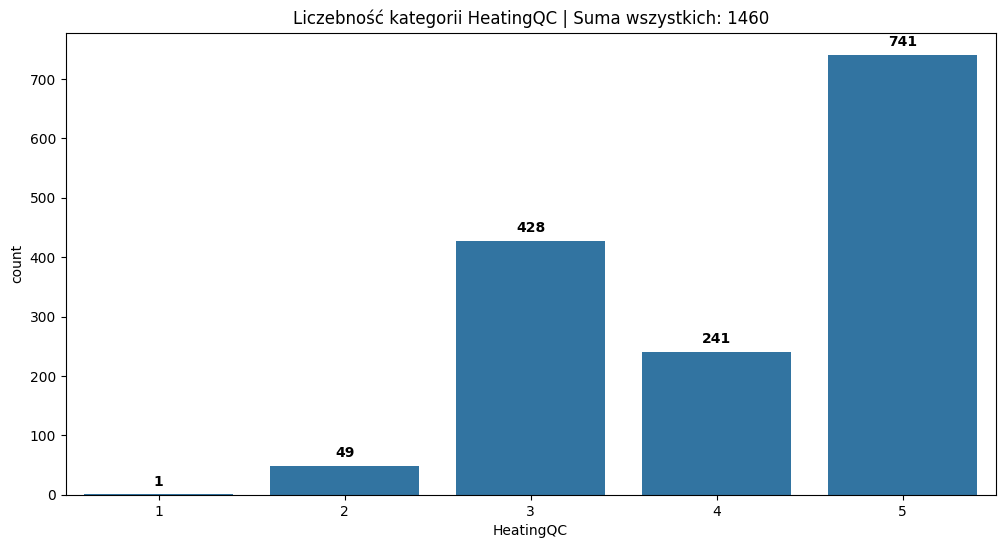

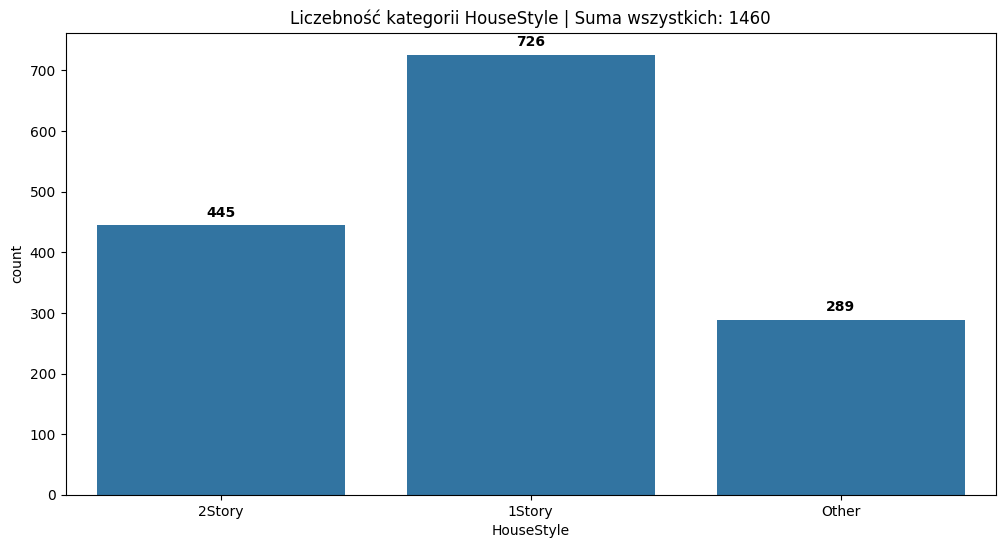

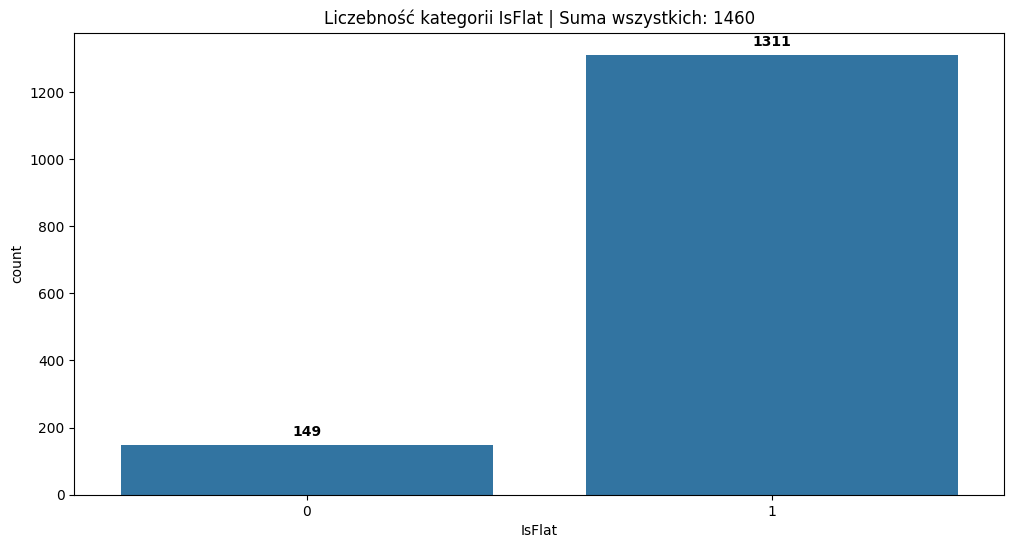

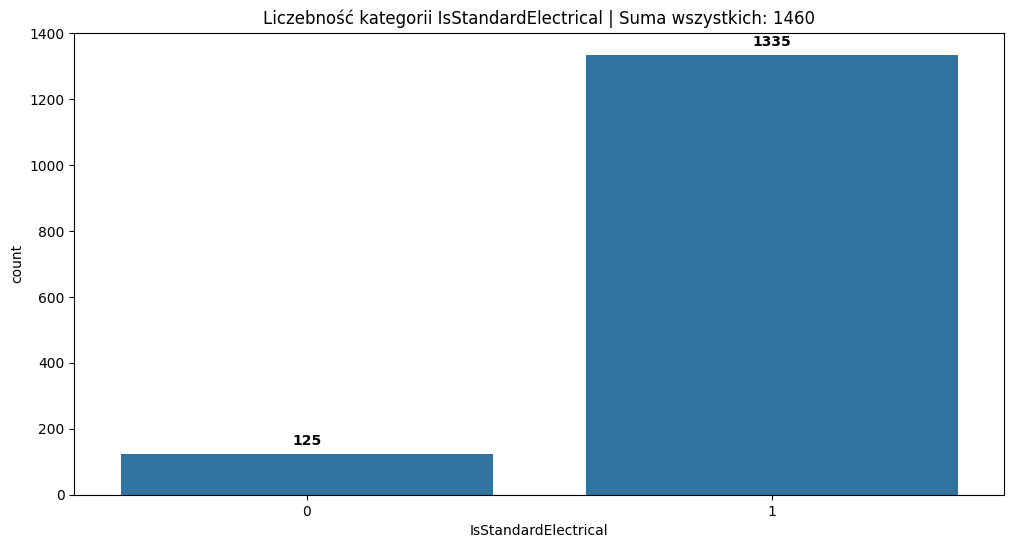

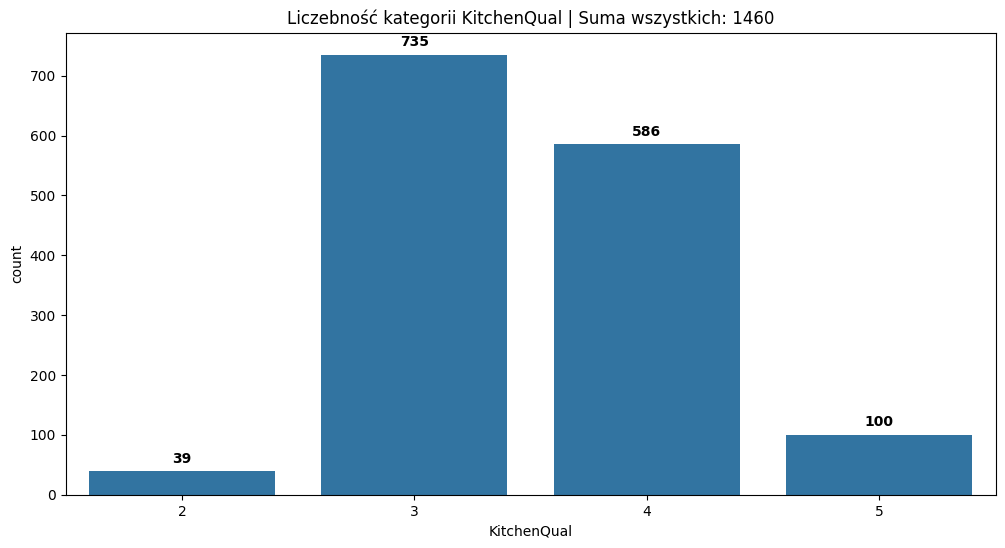

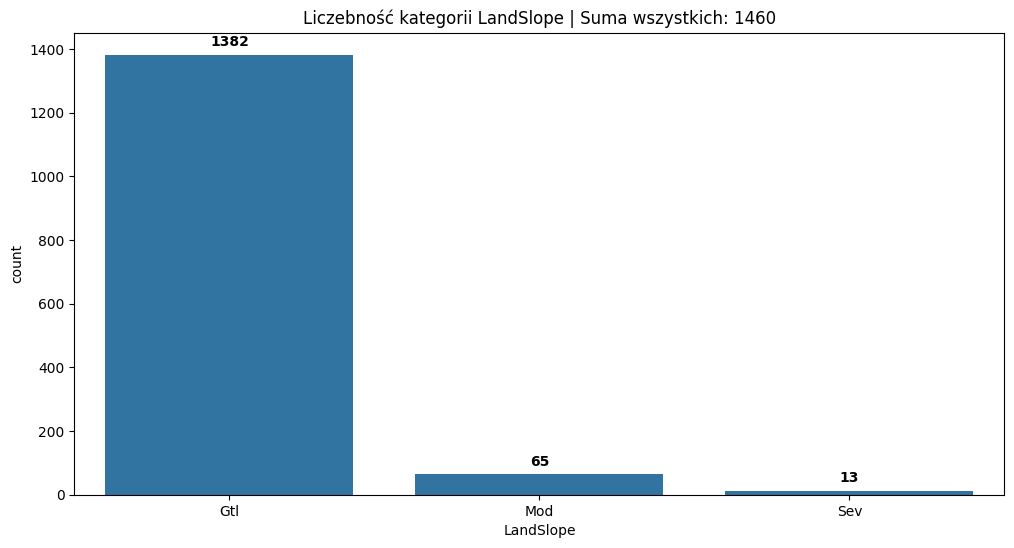

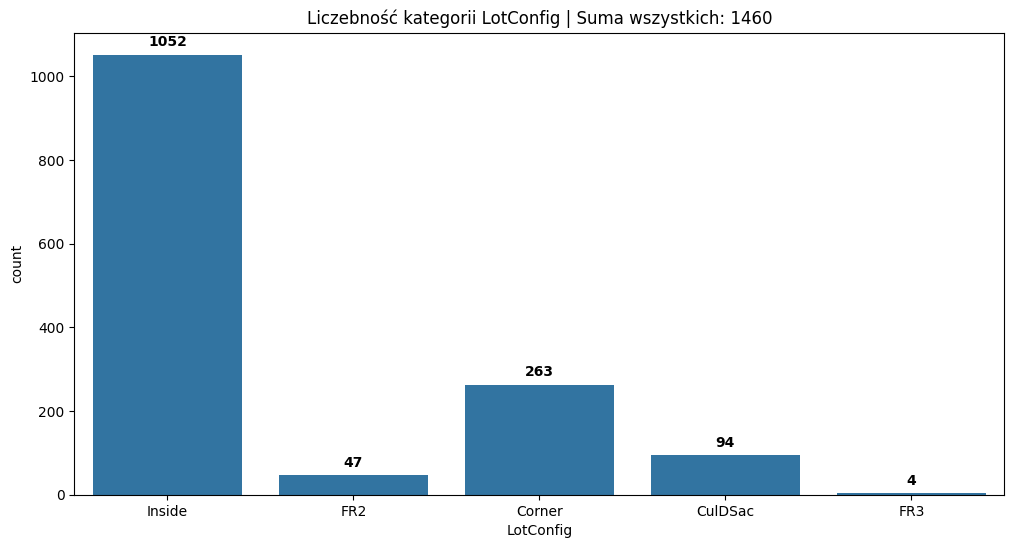

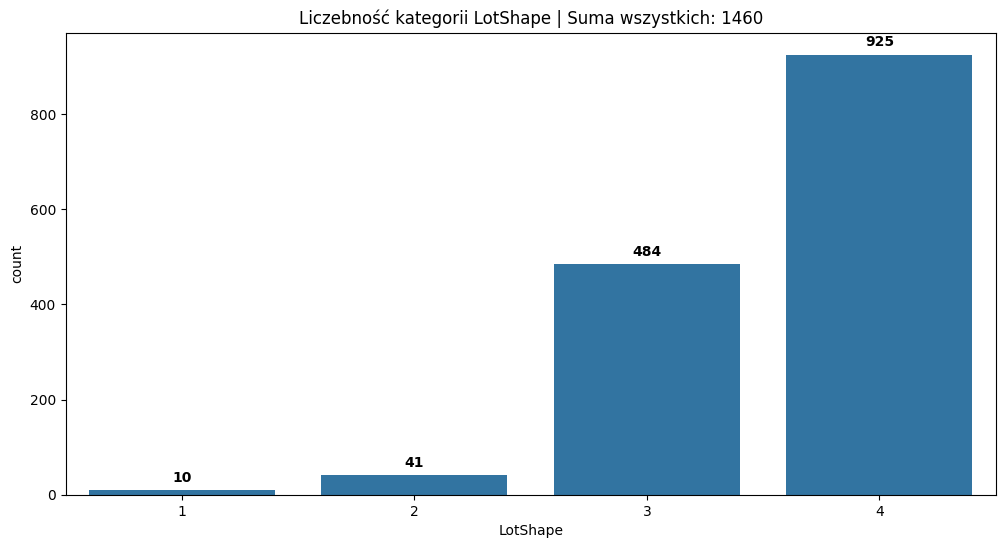

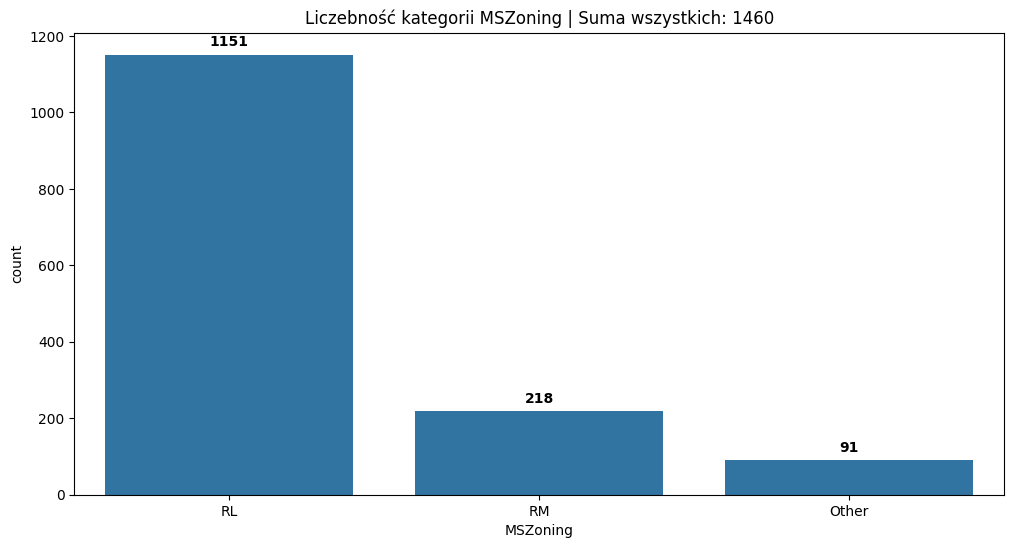

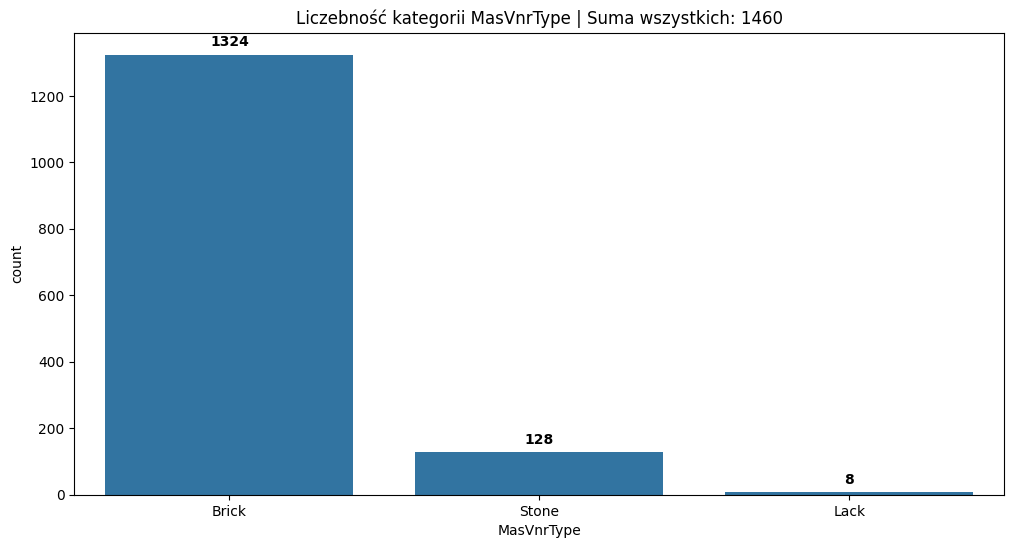

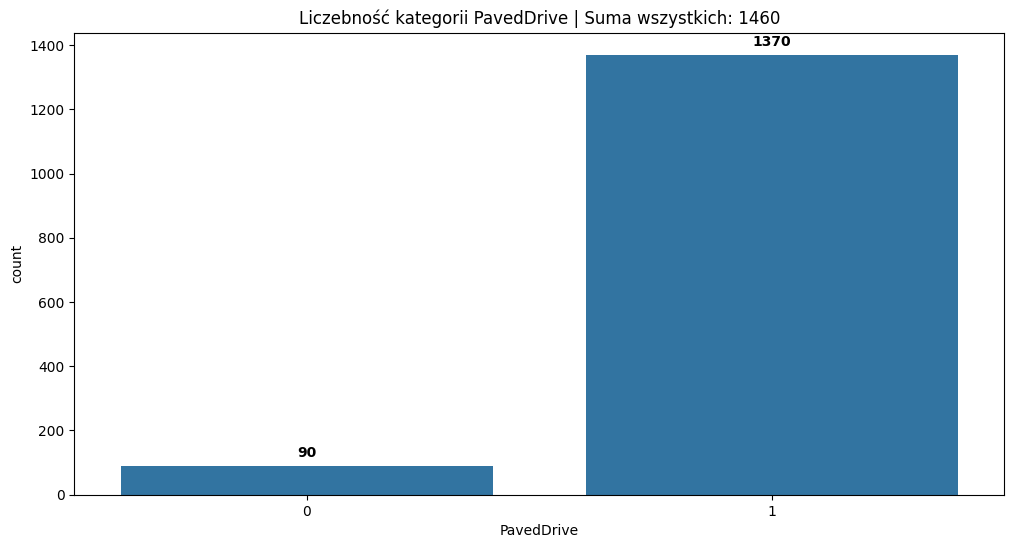

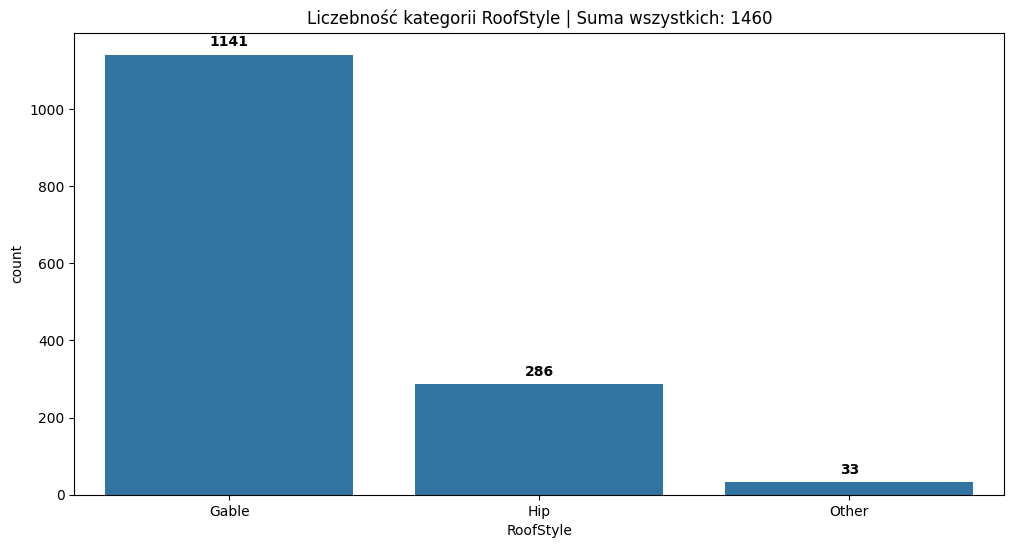

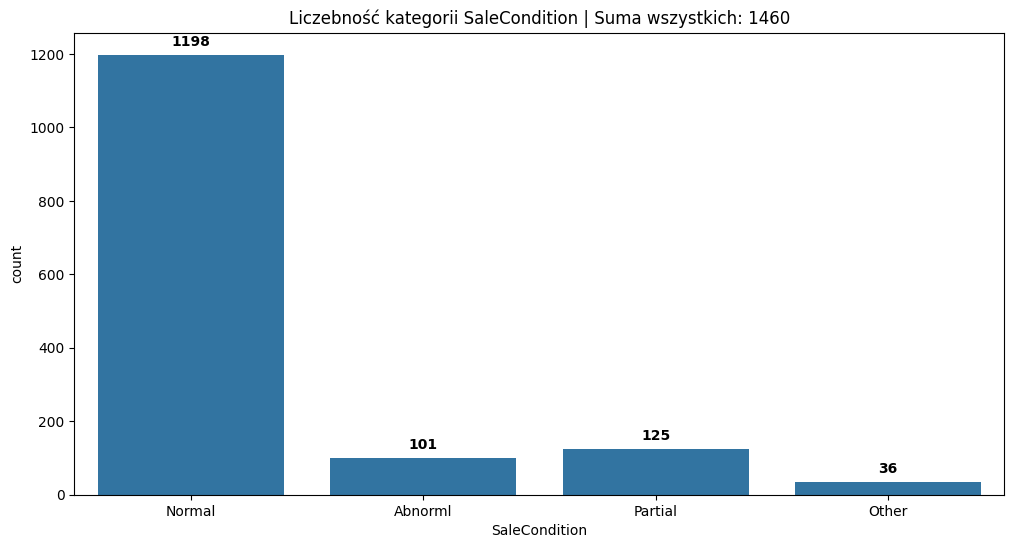

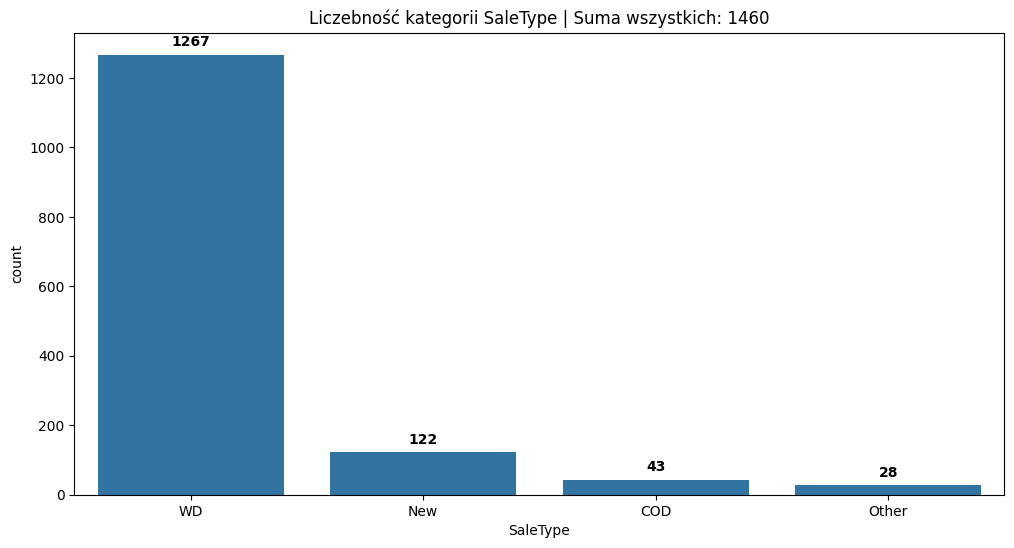

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_features_s = [col for col in cat_features_s if col in df.columns]
df_cat_s = df[cat_features_s]

df_cat_s = df_cat_s.sort_index(axis=1)

for col in df_cat_s.columns:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(data=df_cat_s, x=col)
    
    # 1. Zliczenie sumy wszystkich słupków na danym wykresie
    total_count = sum(int(p.get_height()) for p in ax.patches)
    
    # Dodawanie liczb nad słupkami
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(format(height, '.0f'), 
                       (p.get_x() + p.get_width() / 2., height), 
                       ha='center', va='center', 
                       xytext=(0, 9), 
                       textcoords='offset points',
                       fontsize=10,
                       fontweight='bold')
    
    # 2. Wyświetlenie sumy w tytule za pomocą f-stringa
    plt.title(f"Liczebność kategorii {col} | Suma wszystkich: {total_count}")
    plt.show()

In [31]:
for col in df:
    if df[col].dtype == 'str':
        print(col + ": " + str(df[col].dtype))

In [32]:
kolumny_tekstowe = df.select_dtypes(include=['object', 'string']).columns.tolist()
kolumny_do_kodowania = [col for col in kolumny_tekstowe if col not in ['Exterior1st', 'Exterior2nd', 'Neighborhood']]

df = pd.get_dummies(df, columns=kolumny_do_kodowania, dtype=int)

In [33]:
df

,1stFlrSF,2ndFlrSF,3SsnPorch,BedroomAbvGr,BsmtCond,BsmtExposure,BsmtFinSF1,BsmtFinSF2,BsmtFinType1Ovrl,BsmtFullBath,BsmtHalfBath,BsmtQual,BsmtUnfSF,CentralAir,IsStandardElectrical,EnclosedPorch,ExterCond,ExterQual,Exterior1st,Exterior2nd,FenceOvrl,FireplaceQu,Fireplaces,FullBath,GarageArea,GarageCars,GarageCond,GarageFinish,GarageQual,GarageYrBlt,GrLivArea,HalfBath,HeatingQC,Id,KitchenAbvGr,KitchenQual,IsFlat,LotArea,LotFrontage,LotShape,LowQualFinSF,MSSubClass,MasVnrArea,MiscVal,MoSold,Neighborhood,OpenPorchSF,OverallCond,OverallQual,PavedDrive,PoolArea,SalePrice,ScreenPorch,TotRmsAbvGrd,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,YrSold,Alley_Grvl,Alley_NoAlley,Alley_Pave,BldgType_1Fam,BldgType_Other,Condition1_Noise,Condition1_Norm,Condition1_Pos,Foundation_CBlock,Foundation_Other,Foundation_PConc,GarageType_Attchd,GarageType_Detchd,GarageType_Other,HouseStyle_1Story,HouseStyle_2Story,HouseStyle_Other,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,MSZoning_Other,MSZoning_RL,MSZoning_RM,MasVnrType_Brick,MasVnrType_Lack,MasVnrType_Stone,RoofStyle_Gable,RoofStyle_Hip,RoofStyle_Other,SaleCondition_Abnorml,SaleCondition_Normal,SaleCondition_Other,SaleCondition_Partial,SaleType_COD,SaleType_New,SaleType_Other,SaleType_WD
0,856,854,0,3,3,1,706,0,6,1,0,4,150,1,1,0,3,4,VinylSd,VinylSd,0,0,0,2,548,2,3,2,3,2003.0,1710,1,5,1,1,4,1,8450,65.0,4,0,60,196.0,0,2,CollgCr,61,5,7,1,0,208500,0,8,856,0,2003,2003,2008,0,1,0,1,0,0,1,0,0,0,1,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
1,1262,0,0,3,3,4,978,0,5,0,1,4,284,1,1,0,3,3,MetalSd,MetalSd,0,3,1,2,460,2,3,2,3,1976.0,1262,0,5,2,1,3,1,9600,80.0,4,0,20,0.0,0,5,Veenker,0,8,6,1,0,181500,0,6,1262,298,1976,1976,2007,0,1,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
2,920,866,0,3,3,2,486,0,6,1,0,4,434,1,1,0,3,4,VinylSd,VinylSd,0,3,1,2,608,2,3,2,3,2001.0,1786,1,5,3,1,4,1,11250,68.0,3,0,60,162.0,0,9,CollgCr,42,5,7,1,0,223500,0,6,920,0,2001,2002,2008,0,1,0,1,0,0,1,0,0,0,1,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
3,961,756,0,3,4,1,216,0,5,1,0,3,540,1,1,272,3,3,'Wd Sdng','Wd Shng',0,4,1,1,642,3,3,1,3,1998.0,1717,0,4,4,1,4,1,9550,60.0,3,0,70,0.0,0,2,Crawfor,35,5,7,1,0,140000,0,7,756,0,1915,1970,2006,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1
4,1145,1053,0,4,3,3,655,0,6,1,0,4,490,1,1,0,3,4,VinylSd,VinylSd,0,3,1,2,836,3,3,2,3,2000.0,2198,1,5,5,1,4,1,14260,84.0,3,0,60,350.0,0,12,NoRidge,84,5,8,1,0,250000,0,9,1145,192,2000,2000,2008,0,1,0,1,0,0,1,0,0,0,1,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,953,694,0,3,3,1,0,0,1,0,0,4,953,1,1,0,3,3,VinylSd,VinylSd,0,3,1,2,460,2,3,2,3,1999.0,1647,1,5,1456,1,3,1,7917,62.0,4,0,60,0.0,0,8,Gilbert,40,5,6,1,0,175000,0,7,953,0,1999,2000,2007,0,1,0,1,0,0,1,0,0,0,1,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
1456,2073,0,0,3,3,1,790,163,5,1,0,4,589,1,1,0,3,3,Plywood,Plywood,1,3,2,2,500,2,3,1,3,1978.0,2073,0,3,1457,1,3,1,13175,85.0,4,0,20,119.0,0,2,NWAmes,0,6,6,1,0,210000,0,7,1542,349,1978,1988,2010,0,1,0,1,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1
1457,1188,1152,0,4,4,1,275,0,6,0,0,3,877,1,1,0,4,5,CemntBd,CmentBd,2,4,2,2,252,1,3,2,3,1941.0,2340,0,5,1458,1,4,1,9042,66.0,4,0,70,0.0,2500,5,Crawfor,60,9,7,1,0,266500,0,9,1152,0,1941,2006,2010,0,1,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1
1458,1078,0,0,2,3,2,49,1029,6,1,0,3,0,1,0,112,3,3,MetalSd,MetalSd,0,0,0,1,240,1,3,1,3,1950.0,1078,0,4